In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.io import MemoryFile
from shapely import Polygon, Point
from os import cpu_count
from concurrent.futures import ThreadPoolExecutor
from threading import Lock
import pickle
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from src.mslandcover.config import MSTM_PROJ4

plt.rcParams['font.family'] = 'Times New Roman'

In [ ]:
# define MSTM projection and load census boundaries file
ms_gdf = gpd.read_file('./data/sampling/cb_2023_28_bg_500k').to_crs(MSTM_PROJ4)
ms_polygon = ms_gdf.dissolve().geometry[0]

In [ ]:
# create grid over Mississippi
x_min, y_min, x_max, y_max = ms_polygon.bounds
x_delta, y_delta = 256, 256

grid_gdf = gpd.GeoDataFrame(
    geometry=[Polygon([
        (x, y), 
        (x+x_delta, y),
        (x+x_delta, y+y_delta),
        (x, y+y_delta),
    ]) for x in np.arange(x_min, x_max, x_delta) for y in np.arange(y_min, y_max, y_delta)], 
    crs=MSTM_PROJ4,
)

# keep only the grid cells that intersect the state
grid_gdf = grid_gdf.loc[grid_gdf.intersects(ms_polygon)]
grid_gdf.to_parquet('./data/sampling/grid_MSTM.par') # NOTE: this file is in MSTM projection

In [ ]:
# reproject to MSTM
with rio.open('./data/sampling/NLCD/Annual_NLCD_LndCov_2023_CU_C1V0.tif') as src:
    
    dest_transform, dest_width, dest_height = calculate_default_transform(
        src.crs, 
        MSTM_PROJ4, 
        src.width, 
        src.height, 
        *src.bounds
    )
    
    out_meta = src.meta.copy()
    out_meta.update({
        'crs': MSTM_PROJ4,
        'transform': dest_transform,
        'width': dest_width,
        'height': dest_height,
    })
    
    with rio.open('./data/sampling/NLCD/NLCD_CONUS_MSTM.tif', 'w', **out_meta) as dst:
        
        reproject(
            source=rio.band(src, 1),
            destination=rio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs, 
            dst_transform=dest_transform,
            dst_crs=MSTM_PROJ4, 
            resampling=Resampling.nearest,
        )

In [ ]:
# load reprojected data and mask to grid

# could use state boundary, but some cells slightly protrude outside of the state
# better to use grid boundary
full_grid = grid_gdf.dissolve().geometry

with rio.open('./data/sampling/NLCD/NLCD_CONUS_MSTM.tif') as src:
    
    out_image, out_transform = mask(src, full_grid, crop=True, all_touched=True)
    out_meta = src.meta.copy()
    out_meta.update({
        'height': out_image.shape[1],
        'width': out_image.shape[2],
        'transform': out_transform,
    })
    
    # save masked data
    with rio.open(f'./data/sampling/NLCD/NLCD_MS.tif', 'w', **out_meta) as dst:
        dst.write(out_image)

In [ ]:
# converting from NLCD Level II to Level I classes
# I thought about this a lot - originally, I clustered and selected samples
# based off the Level II legend information (since it's more detailed), but since
# the level I classes are what will be used in the downstream classification, I 
# decided to pivot to using the Level I classes for the clustering and sample selection

# This probably warrants a further discussion, but I think it's a reasonable choice

# NLCD Level I classes (https://www.mrlc.gov/data/legends/national-land-cover-database-class-legend-and-description)
## 0: nodata
## 1: water
## 2: developed
## 3: barren
## 4: forest
## 5: shrubland
## 6: herbaceous
## 7: cultivated
## 8: wetlands

with rio.open('./data/sampling/NLCD/NLCD_MS.tif') as src:
    nlcd_ms_data = src.read(1)
    nlcd_ms_meta = src.meta
    
# print(nlcd_ms_data.shape)

# reclassify NLCD level II classes to Level I classes
nlcd_level_I_data = nlcd_ms_data.copy()
nlcd_level_I_data = np.where(nlcd_level_I_data != 250, nlcd_level_I_data / 10, 0)
nlcd_level_I_data = np.where(nlcd_level_I_data > 6, nlcd_level_I_data - 1, nlcd_level_I_data)
nlcd_level_I_data = np.where(nlcd_level_I_data == 250, 0, nlcd_level_I_data)
print(nlcd_level_I_data.shape)
# nlcd_level_I_data = nlcd_level_I_data[nlcd_level_I_data != 250] / 10

# nlcd_level_I_data = nlcd_level_I_data[nlcd_level_I_data >= 7] - 1
# nlcd_level_I_data = np.where(nlcd_level_I_data == 250, 0, nlcd_level_I_data)

print(nlcd_level_I_data.shape)

# update metadata
nlcd_level_I_meta = nlcd_ms_meta.copy()
nlcd_level_I_meta.update({
    'dtype': rio.uint8,
    'count': 1,
    'nodata': 0,
    'compress': 'lz77',
})

with rio.open('./data/sampling/NLCD/NLCD_MS_level_1.tif', 'w', **nlcd_level_I_meta) as dst:
    dst.write(nlcd_level_I_data, 1)

In [ ]:
# now for the fun part: extract zonal histograms from each grid cell
def extract_zonal_histogram(geom, src, lock):
    with lock:
        out_image, _ = mask(src, [geom], crop=True, all_touched=False, nodata=250)
    return dict(zip(*np.unique(out_image[0], return_counts=True)))

lock = Lock()
n_cpus = cpu_count()

with MemoryFile(open('./data/sampling/NLCD/NLCD_MS_level_1.tif', 'rb')) as memfile:
    with rio.open(memfile) as src:
        with ThreadPoolExecutor(4 * n_cpus) as executor:
            grid_counts = executor.map(
                lambda geom: extract_zonal_histogram(geom, src, lock),
                grid_gdf.geometry,
            )

# save grid counts
grid_counts = list(grid_counts)
with open('./data/sampling/grid_counts.pkl', 'wb') as f:
    pickle.dump(grid_counts, f)

In [ ]:
# transform list of dicts with counts to list of vectors corresponding to histograms 
# that are all of the same dimensionality based on the unique values in the raster

# get unique values in data
unique_values = np.unique(np.concatenate([list(gc.keys()) for gc in grid_counts]))
values_map = {v: i for i, v in enumerate(unique_values)}

# create vectors of histograms
histograms = np.zeros((len(grid_counts), len(unique_values) - 1), dtype=int) # -1 to exclude nodata value
for i, grid_count in enumerate(grid_counts):
    for k, v in grid_count.items():
        # do not inlude nodata values (250)
        if k == 250:
            continue
        histograms[i, values_map[k]] = v

# normalize histograms (each vector sums to 1)
histograms = histograms / histograms.sum(axis=1, keepdims=True)
np.save('./data/sampling/histogram_vectors.npy', histograms)

In [ ]:
# time to perform PCA and cluster
n_components = 2
n_clusters = 250
random_state = 1701

scaler = RobustScaler() # robust to outliers
pca = PCA(n_components=n_components, random_state=random_state)
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)

hist_scaled = scaler.fit_transform(histograms)
hist_pca = pca.fit_transform(hist_scaled)

grid_gdf['hist_vector'] = [v for v in histograms]
grid_gdf['hist_vector_scaled'] = [v for v in hist_scaled]
grid_gdf['hist_vector_pca'] = [v for v in hist_pca]

print(f'Percent of variance explained by {n_components} principal components: {100*pca.explained_variance_ratio_.sum():.2f}%')
for i in range(pca.n_components_):
    print(f'PC{i+1} explains {100*pca.explained_variance_ratio_[i]:.2f}% of variance')

clusters = kmeans.fit_predict(hist_pca)
grid_gdf['cluster'] = clusters
print(f'Number of clusters: {n_clusters}')
print(f'Minimum number of samples in a cluster: {np.unique(clusters, return_counts=True)[1].min()}')

grid_gdf.to_parquet(f'./data/sampling/grid_MSTM_{n_clusters}_clusters.par')

Percent of variance explained by 2 principal components: 90.54%
PC1 explains 61.41% of variance
PC2 explains 29.14% of variance


/Users/dak/.virtualenvs/detection/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Number of clusters: 250
Minimum number of samples in a cluster: 365


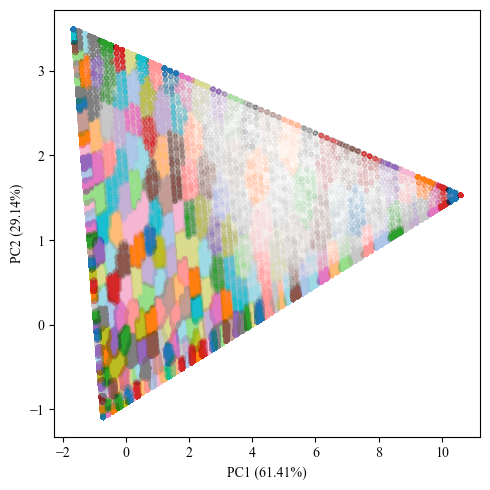

In [ ]:
# plot clusters in PC space
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(hist_pca[:, 0], hist_pca[:, 1], c=clusters, cmap='tab20', s=10, alpha=0.01)
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.2f}%)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.2f}%)')
fig.tight_layout()
plt.savefig(f'./figures/sampling/clusters_{n_clusters}.png', dpi=300)
plt.show()

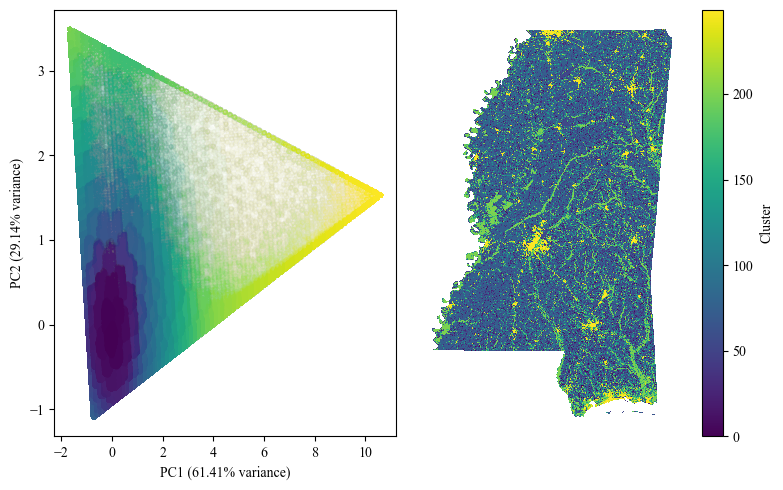

In [ ]:
# visualize clusters on map
grids_copy = grid_gdf.copy()

# order the clusters such that they can be colored in a way that clusters with
# similar values have similar colors
# get cluster centers
cluster_centers = pca.inverse_transform(kmeans.cluster_centers_)
# cluster_centers = scaler.inverse_transform(cluster_centers)

# get the order of the clusters based on the cluster centers
cluster_order = np.argsort(np.sum(np.square(kmeans.cluster_centers_), axis=1))

# map the cluster order to the original cluster labels
cluster_map = {cluster: i for i, cluster in enumerate(cluster_order)}
grids_copy['cluster'] = grids_copy['cluster'].map(cluster_map)

# plot clusters using PCs
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

scatter = ax[0].scatter(hist_pca[:, 0], hist_pca[:, 1], c=grids_copy['cluster'], cmap='viridis', s=10, alpha=0.01)
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')

grids_copy.plot(column='cluster', ax=ax[1], legend=True, cmap='viridis', legend_kwds={'label': 'Cluster'})
ax[1].axis('off')

fig.tight_layout()
# plt.show()
plt.savefig('./figures/sampling/clusters_map.png', dpi=300)

In [ ]:
# sample pathces for training, testing, and validation sets - for each cluster, sample 4 patches
n_train_samples_per_cluster = 2
n_val_samples_per_cluster = 1
n_test_samples_per_cluster = 1
n_pretraining_samples = int(0.2 * len(grid_gdf)) # sample 20% of total patches for pretraining

train_patches_gdf = grid_gdf.groupby('cluster').sample(n=n_train_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = grid_gdf[~grid_gdf.index.isin(train_patches_gdf.index)]

val_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_val_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(val_patches_gdf.index)]

test_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_test_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(test_patches_gdf.index)]

# sample pretraining last to enforce disjoint splits
pretraining_patches_gdf = remaining_candidate_patches_gdf.sample(n=n_pretraining_samples, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(pretraining_patches_gdf.index)]

print(f'Number of pretraining samples: {len(pretraining_patches_gdf)}')
print(f'Number of training samples: {len(train_patches_gdf)}')
print(f'Number of validation samples: {len(val_patches_gdf)}')
print(f'Number of testing samples: {len(test_patches_gdf)}')

for df, name in zip([train_patches_gdf, val_patches_gdf, test_patches_gdf, pretraining_patches_gdf], ['train', 'val', 'test', 'pretrain']):
    df['split'] = name

samples_gdf = pd.concat([pretraining_patches_gdf, train_patches_gdf, val_patches_gdf, test_patches_gdf])
samples_gdf.to_parquet('samples.par')
remaining_candidate_patches_gdf.to_parquet('./data/sampling/remaining_candidate_patches.par')

Number of pretraining samples: 377921
Number of training samples: 500
Number of validation samples: 250
Number of testing samples: 250


In [ ]:
# save centroids of train, val, and test patches for visualization later
tvt_gdf = samples_gdf.loc[samples_gdf['split'].isin(['train', 'val', 'test'])].copy()
tvt_gdf['geometry'] = tvt_gdf['geometry'].map(lambda x: x.centroid)
tvt_gdf[['split', 'cluster', 'geometry']].to_file('./data/sampling/tvt_centroids.gpkg', driver='GPKG')

In [37]:
# Ideally, we want to minimize the number of patches that are entirely of one class
def mono_class(hist_vector):
    return sum(hist_vector == 1.0) == 1

full_grid_percent_single_class = 100 * len(grid_gdf[grid_gdf['hist_vector'].apply(mono_class)]) / len(grid_gdf)
samples_percent_single_class = 100 * len(tvt_gdf[tvt_gdf['hist_vector'].apply(mono_class)]) / len(tvt_gdf)

print(f'Percentage of patches that are entirely of one class in full grid: {full_grid_percent_single_class:.2f}%')
print(f'Percentage of patches that are entirely of one class in samples: {samples_percent_single_class:.2f}%')

Percentage of patches that are entirely of one class in full grid: 24.67%
Percentage of patches that are entirely of one class in samples: 1.50%
